# 18g — Refugia transform conditionality (E20 / PF-1 and PF-2): the transform-conditional share of the core

Reads the registered S0@SSP585 guarded run (`runs_v3.1/s0_ssp585_theta5/`) and every E20 arm that has been solved —
`e20_log` (PF-1: saturating refugia, 18e) and `e20_consistent` (PF-2: saturating refugia + convex transboundary connectivity, 18f).
f = share of the 51 plans (anchor + 50 guarded members) selecting a cell. Arms not yet on disk are skipped with a note.

Pre-registered reading (M4.34 / M4.35): the v3.1 core (F ≥ 0.70 over the 12 design formulations) is partitioned by whether S0@585 keeps
each cell frequent (f ≥ 0.70) under the registered shapes and under the variant. **Transform-conditional share** = of the core cells S0
keeps frequent under the registered shapes, the fraction it drops under the variant. Also: whole-core survival, the composition of
surviving / lost / gained cells (densest refugia, soil-carbon tail, the connectivity spike, multi-claim land), the two S0 tiers' areas
and Jaccard, the anchors' agreement. Products: `spec/v3.1/E20_transform_conditionality.json` (keyed by arm) + CSVs, `figures/v3.1/e20_s0_f_arms.png`.

In [1]:
# ---- bootstrap ----------------------------------------------------------------------------------------------
import importlib, json, pathlib, sys, textwrap
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.py").exists()]
ROOT = _cands[0]; sys.path.insert(0, str(ROOT))
import config, leverage_core as lc, ensemble_core as ec, director_core as dc
for _m in (config, lc, ec, dc):
    importlib.reload(_m)
VP = dc.VP; assert VP.version == "v3.1"
G = dc.grid(); RUNS, REC, PKG = dc.RUNS, dc.SPEC_REC, dc.PKG; THR = dc.FREQ_THR
FIG = ROOT / "analyses" / "y2y" / "figures" / VP.version; FIG.mkdir(exist_ok=True, parents=True)
E20 = json.loads((REC / "e20_refugia_transform.json").read_text()); FID = E20["base_formulation"]
ARMS = E20.get("arms") or {"e20_log": dict(label=f"PF-1: {E20['variant']}", out_rel="analyses/y2y/runs_v3.1/e20_log")}
def f_of(cd):
    A = ec.read_selections(cd / "anchor.tif", G.pu)[0]
    S = np.vstack([A[None, :], ec.read_selections(cd / "mga_guard_g05.tif", G.pu)])
    return S.mean(axis=0).astype(np.float32), A
REG_DIR = RUNS / FID; f_reg, a_reg = f_of(REG_DIR); meta_reg = json.loads((REG_DIR / "formulation_meta.json").read_text())
RUNSET = {}
for arm, spec in ARMS.items():
    cd = ROOT / spec["out_rel"] / FID
    if not (cd / "mga_guard_g05.tif").exists():
        print(f"{arm}: not solved yet ({spec['label']}) -- skipped"); continue
    f, a = f_of(cd); cert = pd.read_csv(cd / "certificates_guard.csv"); meta = json.loads((cd / "formulation_meta.json").read_text())
    RUNSET[arm] = dict(f=f, a=a, meta=meta, cert=cert, label=spec["label"])
    print(f"{arm}: {spec['label']} | anchor z {meta['anchor_objective']:.4f} (registered {meta_reg['anchor_objective']:.4f}) | {len(cert)} members"
          + (f", in band {int(cert.in_band.sum())}" if "in_band" in cert else "") + (f", time-limited {int(cert.time_limited.sum())}" if "time_limited" in cert else ""))
assert RUNSET, "no E20 arm solved yet: run 18e (PF-1) and/or 18f (PF-2) first"
with rasterio.open(PKG / "geotiffs" / "act_tiers_guarded.tif") as s:
    tiers = s.read(1)[G.pu]
core = tiers == 3
DM = dc.driver_masks(G)
with rasterio.open(PKG / "geotiffs" / "value_convergence.tif") as s:
    conv = s.read(1)[G.pu]


e20_log: PF-1: saturating refugia (log1p(1/v)) | anchor z 4.9513 (registered 4.9025) | 50 members
e20_consistent: not solved yet (PF-2: consistent set -- saturating refugia + convex transboundary connectivity (weight only, t = 1) + convex corridors) -- skipped
e20_consistent_target: not solved yet (optional: the consistent set WITH R2's connectivity target (t = 0.198)) -- skipped
e20_pf3_A_s0: not solved yet (PF-3 A @ S0: five blocks at 20% (transboundary, corridors separate) -- shares {"core_habitat": 0.2, "transboundary": 0.2, "corridors": 0.2, "carbon": 0.2, "biodiversity": 0.2}) -- skipped
e20_pf3_A_s2: not solved yet (PF-3 A @ S2: five blocks at 20% (transboundary, corridors separate) -- shares {"core_habitat": 0.167, "transboundary": 0.25, "corridors": 0.25, "carbon": 0.167, "biodiversity": 0.167}) -- skipped
e20_pf3_B_s0: not solved yet (PF-3 B @ S0: corridors removed, transboundary alone at the connectivity block's share -- shares {"core_habitat": 0.25, "connectivity": 0.25, "c

driver masks: m_soc theta-tail 51,698 cells | refugia densest (same area) | spike 2,546 | rare-attainable EFG footprint 886,424 cells (70% of PU) from 17/20 EFGs | rarest-EFG footprint 7,504 cells (0.6%) from 2 EFGs


In [2]:
# ---- the transform-conditional share, per arm ------------------------------------------------------------------------
tier_reg = (f_reg >= THR) & G.disc; base = core & tier_reg
OUT, COMPS = {}, {}
for arm, R in RUNSET.items():
    f_v, a_v = R["f"], R["a"]; tier_v = (f_v >= THR) & G.disc; kept = core & tier_v
    res = dict(label=R["label"],
        core_km2=int(core.sum()), s0_reg_tier_km2=int(tier_reg.sum()), s0_variant_tier_km2=int(tier_v.sum()),
        tiers_jaccard=float((tier_reg & tier_v).sum() / (tier_reg | tier_v).sum()),
        anchors_jaccard=float((a_reg & a_v & G.disc).sum() / ((a_reg | a_v) & G.disc).sum()),
        core_frequent_under_registered_km2=int(base.sum()), core_frequent_under_registered_pct=100 * float(base.sum() / core.sum()),
        core_frequent_under_variant_km2=int(kept.sum()), core_frequent_under_variant_pct=100 * float(kept.sum() / core.sum()),
        core_kept_both_km2=int((base & kept).sum()),
        transform_conditional_share_pct=100 * float(1 - (base & kept).sum() / max(base.sum(), 1)),
        core_mean_f_registered=float(f_reg[core].mean()), core_mean_f_variant=float(f_v[core].mean()),
        core_f_corr=float(np.corrcoef(f_reg[core], f_v[core])[0, 1]))
    units = [("core", core), ("core kept frequent under both", base & kept), ("core lost under the variant", base & ~kept), ("core gained under the variant", kept & ~base),
             ("S0 variant tier (all)", tier_v), ("S0 registered tier (all)", tier_reg)]
    comp = {}
    for nm, m in units:
        comp[nm] = dict(km2=int(m.sum()), **{k: (100 * float(v[m].mean()) if m.any() else np.nan) for k, v in DM.items()},
                        **{"multi-claim (>=2 themes top-30%)": (100 * float((conv[m] >= 2).mean()) if m.any() else np.nan)})
    COMP = pd.DataFrame(comp).T; COMP.to_csv(REC / f"E20_transform_conditionality_{arm}.csv")
    OUT[arm] = dict(res, composition=COMP.round(3).to_dict(orient="index")); COMPS[arm] = COMP
    pd.set_option("display.width", 240)
    print(f"\n== {arm}: {R['label']}"); print(json.dumps({k: v for k, v in res.items() if k != 'label'}, indent=1)); print(COMP.round(1).to_string())
    print(f"TRANSFORM-CONDITIONAL SHARE of the core (S0@585, {arm}): {res['transform_conditional_share_pct']:.1f}% of the {res['core_frequent_under_registered_km2']:,} km2 "
          f"S0 keeps frequent under the registered shapes is dropped; whole-core survival {res['core_frequent_under_registered_pct']:.0f}% -> {res['core_frequent_under_variant_pct']:.0f}%")
(REC / "E20_transform_conditionality.json").write_text(json.dumps(dict(spec="v0.18 PF-1 / PF-2", base_formulation=FID, arms=OUT), indent=2))



== e20_log: PF-1: saturating refugia (log1p(1/v))
{
 "core_km2": 29194,
 "s0_reg_tier_km2": 42733,
 "s0_variant_tier_km2": 36287,
 "tiers_jaccard": 0.8463911021800593,
 "anchors_jaccard": 0.9568728178784011,
 "core_frequent_under_registered_km2": 26499,
 "core_frequent_under_registered_pct": 90.76865109269028,
 "core_frequent_under_variant_km2": 25373,
 "core_frequent_under_variant_pct": 86.91169418373639,
 "core_kept_both_km2": 25352,
 "transform_conditional_share_pct": 4.328465225102828,
 "core_mean_f_registered": 0.9191064238548279,
 "core_mean_f_variant": 0.8718565702438354,
 "core_f_corr": 0.934045289807675
}
                                   km2  m_soc theta-tail  connectivity spike (top 0.2%)  refugia densest (area-matched to the m_soc tail)  rare-attainable EFG footprint  rarest-EFG footprint (rare in the extent+250 km window: <= 1% of the window)  multi-claim (>=2 themes top-30%)
core                           29194.0               2.7                            1.0         

3414

In [3]:
# ---- PF-3 (and every arm): own land, pinch-point pinning, diversity, comparison to the step-2 baseline and to the registered run ------
# own land (E18 definition): the arm's tier outside the frozen core and outside the OTHER named scenarios' registered tiers (SSP585)
spike = DM["connectivity spike (top 0.2%)"] & G.disc                      # allocatable spike cells only (locked cells always have f = 1)
def tier_of(cd):
    f, _ = f_of(cd); return (f >= THR) & G.disc
MAN = dc.package_manifest(pd.read_csv(dc.MANIFEST))                      # formulation ids by scenario at SSP585 (s4 is theta3, not theta5)
FID_OF = {r.scenario_id: r.formulation_id for r in MAN[MAN.climate_level.astype(str).str.startswith("ssp585")].itertuples()}
REG_TIERS = {sid: tier_of(RUNS / FID_OF[sid]) for sid in ("s1", "s2", "s3", "s4")}
def diversity(cd):
    A = ec.read_selections(cd / "anchor.tif", G.pu)[0]; Sg = np.vstack([A[None, :], ec.read_selections(cd / "mga_guard_g05.tif", G.pu)])
    Sd = Sg[:, G.disc].astype(np.float32); sizes = Sd.sum(axis=1); ham = sizes[:, None] + sizes[None, :] - 2 * (Sd @ Sd.T)
    return float(ham.max() / (2 * sizes.mean()))
base_dir = ROOT / ARMS["e20_consistent"]["out_rel"] / FID if "e20_consistent" in ARMS else None
tier_base = tier_of(base_dir) if base_dir is not None and (base_dir / "mga_guard_g05.tif").exists() else None
rows = []
for arm, R in RUNSET.items():
    spec = ARMS[arm]; sid = spec.get("scenario", "s0"); f_v = R["f"]; tier_v = (f_v >= THR) & G.disc
    others = np.zeros(G.n_pu, bool)
    for s_, m in REG_TIERS.items():
        if s_ != sid: others |= m
    ref_dir = RUNS / FID_OF[sid]; tier_ref = tier_of(ref_dir)                # the registered run of the same scenario at SSP585
    own = tier_v & ~core & ~others
    r = dict(arm=arm, scenario=sid, label=spec["label"][:60], tier_km2=int(tier_v.sum()), own_land_km2=int(own.sum()),
             registered_tier_km2=int(tier_ref.sum()), registered_own_km2=int((tier_ref & ~core & ~others).sum()),
             jaccard_vs_registered=float((tier_v & tier_ref).sum() / max((tier_v | tier_ref).sum(), 1)),
             jaccard_vs_step2_baseline=(float((tier_v & tier_base).sum() / max((tier_v | tier_base).sum(), 1)) if tier_base is not None else np.nan),
             core_kept_frequent_pct=100 * float((core & tier_v).sum() / core.sum()),
             spike_in_tier_pct=100 * float(tier_v[spike].mean()), spike_frequent_pct=100 * float((f_v[spike] >= THR).mean()), spike_max_f=float(f_v[spike].max()),
             tier_share_in_spike_pct=100 * float(spike[tier_v].mean()) if tier_v.any() else np.nan,
             tier_share_densest_refugia_pct=100 * float(DM["refugia densest (area-matched to the m_soc tail)"][tier_v].mean()) if tier_v.any() else np.nan,
             tier_multi_claim_pct=100 * float((conv[tier_v] >= 2).mean()) if tier_v.any() else np.nan,
             D=diversity(ROOT / spec["out_rel"] / FID), transboundary_share=(spec.get("block_shares", {}).get("transboundary") or spec.get("block_shares", {}).get("connectivity") or np.nan))
    rows.append(r)
PF3S = pd.DataFrame(rows); PF3S.to_csv(REC / "E20_pf3_summary.csv", index=False)
pd.set_option("display.width", 260)
print("per-arm summary (own land = tier outside the frozen core and the other named scenarios' registered tiers; spike = top 0.2% of raw current):")
print(PF3S.drop(columns=["label"]).to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("\nE18 reference: at identity shapes, transboundary began to own land between per-layer shares 0.33-0.42 (block 0.67-0.83); PF-3 shares here:",
      {a: ARMS[a].get("block_shares", {}) for a in RUNSET if ARMS[a].get("pf3")})


per-arm summary (own land = tier outside the frozen core and the other named scenarios' registered tiers; spike = top 0.2% of raw current):
    arm scenario  tier_km2  own_land_km2  registered_tier_km2  registered_own_km2  jaccard_vs_registered  jaccard_vs_step2_baseline  core_kept_frequent_pct  spike_in_tier_pct  spike_frequent_pct  spike_max_f  tier_share_in_spike_pct  tier_share_densest_refugia_pct  tier_multi_claim_pct     D  transboundary_share
e20_log       s0     36287             0                42733                   0                  0.846                        NaN                  86.912             24.412              24.412        1.000                    1.259                          84.523                90.278 0.838                  NaN

E18 reference: at identity shapes, transboundary began to own land between per-layer shares 0.33-0.42 (block 0.67-0.83); PF-3 shares here: {}


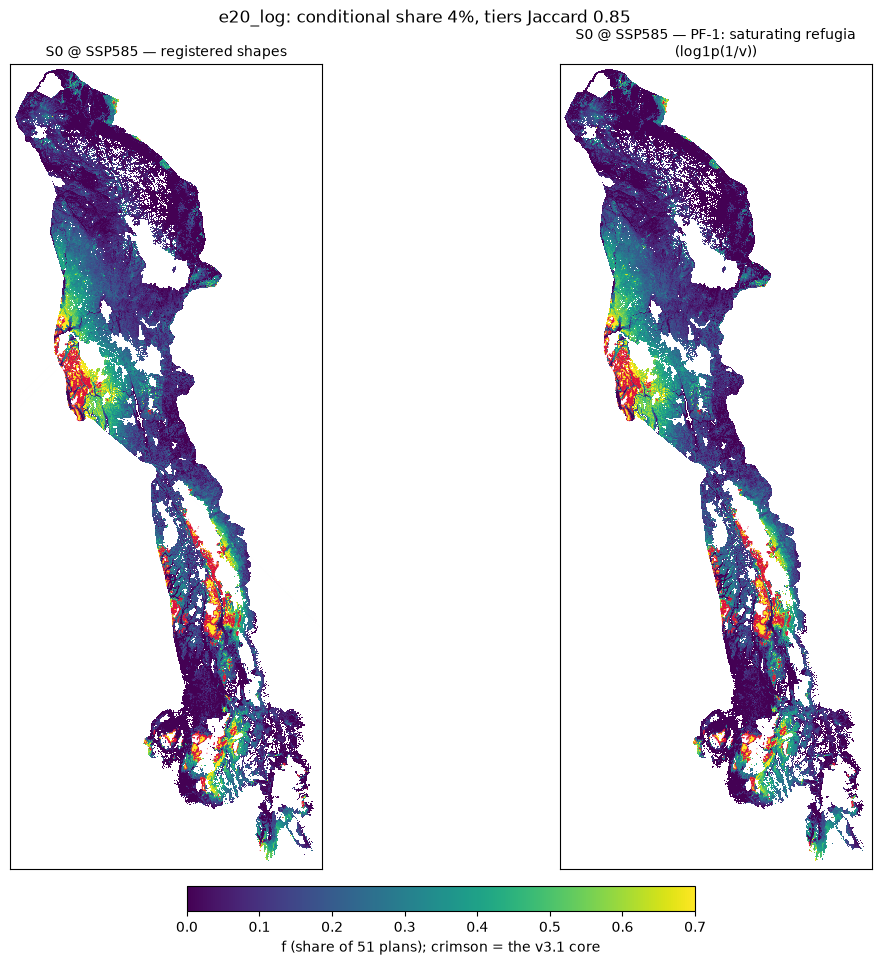

In [4]:
# ---- figure: S0@585 f under the registered shapes and each solved arm, the core outlined -----------------------------
panels = [("S0 @ SSP585 — registered shapes", f_reg)] + [(f"S0 @ SSP585 — {R['label']}", R["f"]) for R in RUNSET.values()]
C2 = dc.to_grid(G, core.astype(np.float32)); C2[~G.pu] = np.nan
fig, axes = plt.subplots(1, len(panels), figsize=(6.5 * len(panels), 11))
for ax, (ttl, f) in zip(np.atleast_1d(axes), panels):
    im = ax.imshow(dc.to_grid(G, np.where(G.disc, f, np.nan)), cmap="viridis", vmin=0, vmax=THR, interpolation="nearest")
    ax.contour(C2, levels=[0.5], colors=["crimson"], linewidths=0.5)
    ax.set_title("\n".join(textwrap.wrap(ttl, 48)), fontsize=10); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.03, pad=0.02, label="f (share of 51 plans); crimson = the v3.1 core")
fig.suptitle(" | ".join(f"{arm}: conditional share {OUT[arm]['transform_conditional_share_pct']:.0f}%, tiers Jaccard {OUT[arm]['tiers_jaccard']:.2f}" for arm in OUT), y=0.93)
fig.savefig(FIG / "e20_s0_f_arms.png", dpi=150, bbox_inches="tight"); plt.show()
